# Commodity forecasting | Availability and market structure

Before selecting features, examine market coverage and the distinct data families. All analysis in this notebook uses the development interval. Raw values and row-level labels are not displayed.

Previous: `00_data_audit.ipynb` · Next: `02_feature_research.ipynb`.

In [1]:
from pathlib import Path
import sys
if not Path("pyproject.toml").exists():
    sys.path.insert(0, str(Path.cwd().parent))
import json
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown
from scripts.notebook_support import project_root, checked_reports, checked_study, show_figure
root = project_root()
audit, research = checked_reports(root)
study = checked_study(root)
study_config = json.loads((root / "configs/feature_study.json").read_text())
config = json.loads((root / "configs/research.json").read_text())
display(Markdown(f"**Verified experiment:** `{study['lineage'][:16]}` · **Feature gate:** open"))

**Verified experiment:** `a904250065ff1ebb` · **Feature gate:** open

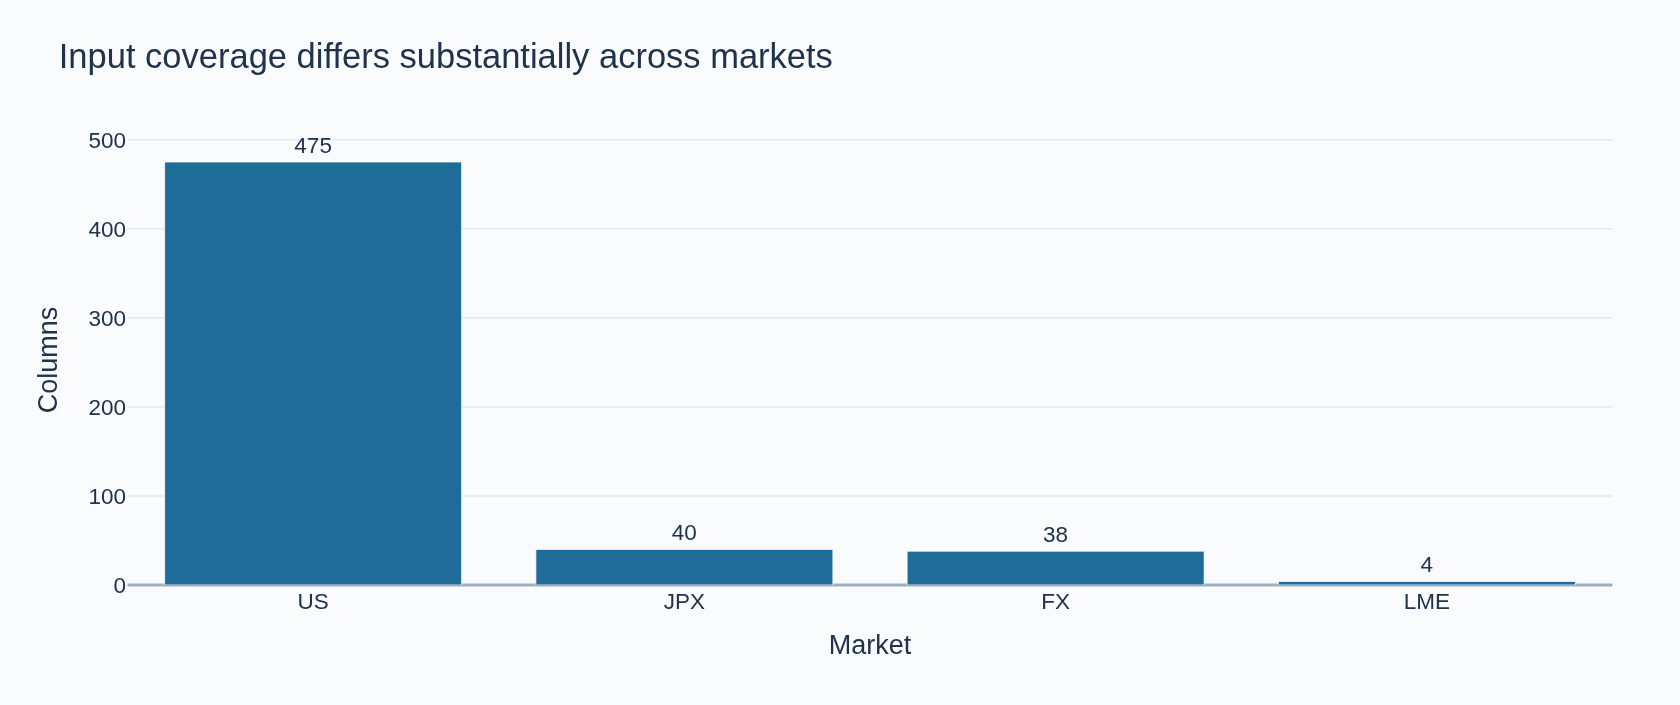

In [2]:
from commodity_prediction.data import load_data
x, y, pairs = load_data(root)
x = x.iloc[:audit["development_dates"]]
y = y.iloc[:audit["development_dates"]]
origins = pd.Series([c.split("_")[0] for c in x.columns]).value_counts().rename_axis("Market").reset_index(name="Columns")
fig = px.bar(origins, x="Market", y="Columns", text="Columns", title="Input coverage differs substantially across markets")
fig.update_traces(marker_color="#1F6C99", textposition="outside")
show_figure(fig, root, "market_coverage", 470)

## Missingness is a market-state signal

Trading holidays, exchange time zones, listing history, and absent observations create structured gaps. Backward filling would import future information. Candidate features therefore preserve missingness, record observation age, and use training-only median imputation during model fitting.

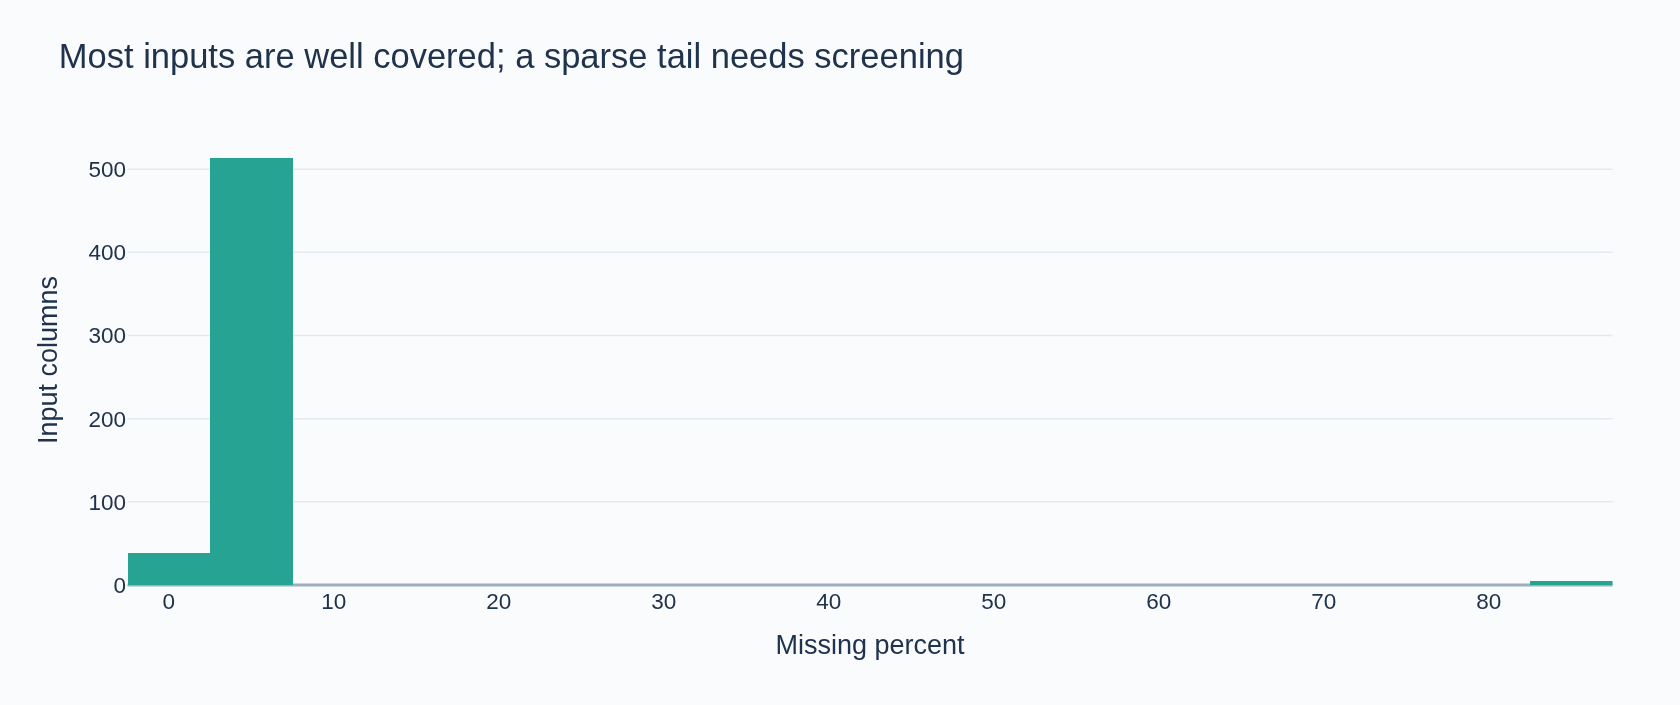

,Count
Screening consideration,
Inputs over 40% missing in development,5
Entirely constant observed inputs,0
Development dates,1709


In [3]:
missing = x.isna().mean().mul(100).rename("Missing percent").rename_axis("Feature").reset_index()
fig = px.histogram(missing, x="Missing percent", nbins=25, title="Most inputs are well covered; a sparse tail needs screening")
fig.update_traces(marker_color="#27A394")
fig.update_layout(yaxis_title="Input columns")
show_figure(fig, root, "missingness_distribution", 470)
display(pd.DataFrame({"Screening consideration": ["Inputs over 40% missing in development", "Entirely constant observed inputs", "Development dates"],
                      "Count": [int((x.isna().mean() > 0.4).sum()), int((x.nunique() < 2).sum()), len(x)]}).set_index("Screening consideration"))

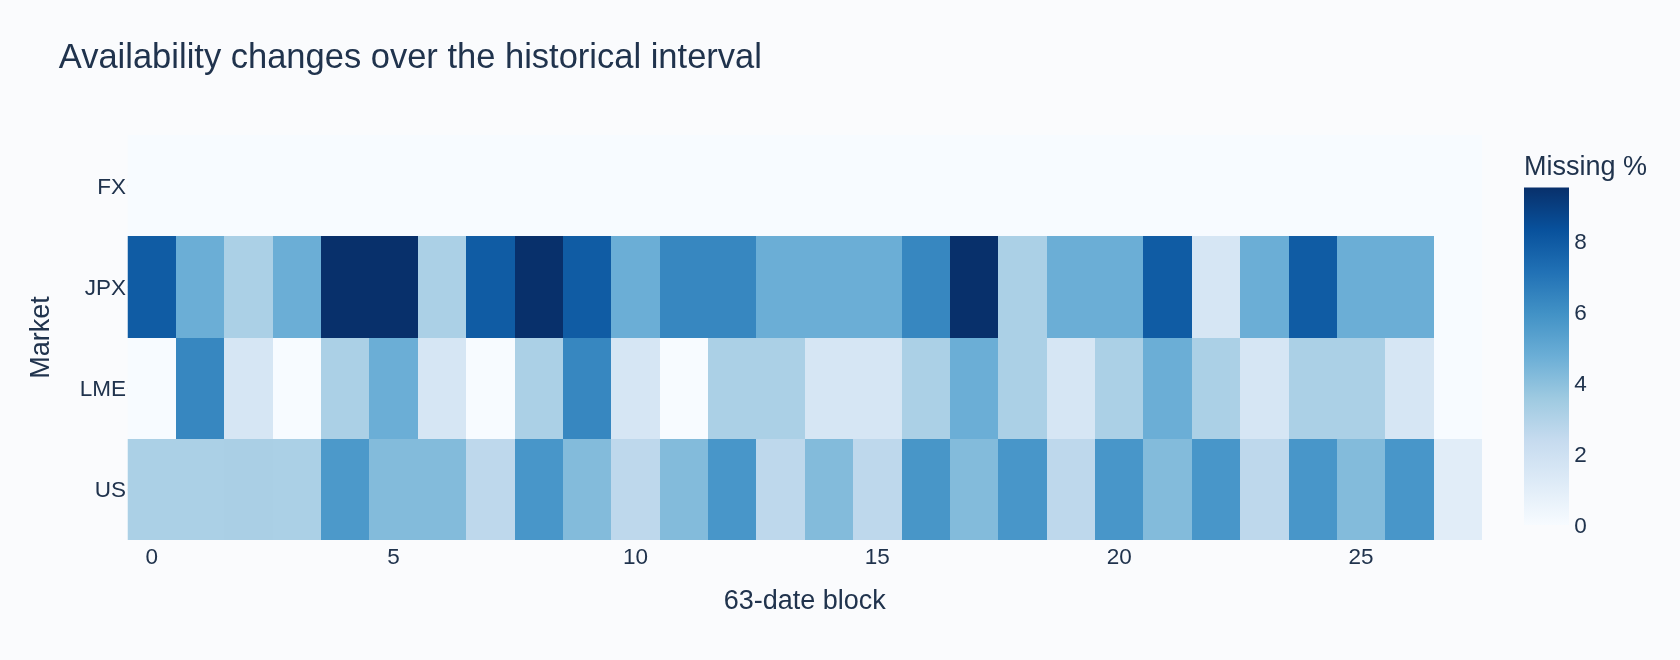

In [4]:
availability = []
for origin in sorted(origins.Market):
    cols = [c for c in x.columns if c.startswith(origin + "_")]
    daily_missing = x[cols].isna().mean(axis=1)
    by_block = daily_missing.groupby(np.arange(len(x)) // 63).mean().mul(100)
    availability.extend({"Market": origin, "63-date block": int(i), "Missing percent": float(v)} for i, v in by_block.items())
matrix = pd.DataFrame(availability).pivot(index="Market", columns="63-date block", values="Missing percent")
fig = px.imshow(matrix, color_continuous_scale="Blues", aspect="auto", title="Availability changes over the historical interval", labels={"color": "Missing %"})
show_figure(fig, root, "availability_over_time", 440)

## Target availability must remain explicit

Missing labels are excluded from each target's fit. The primary metric ranks all observed targets within a date. Horizon-specific diagnostics exclude dates with fewer than two observed targets and report their coverage; they do not change the primary metric.

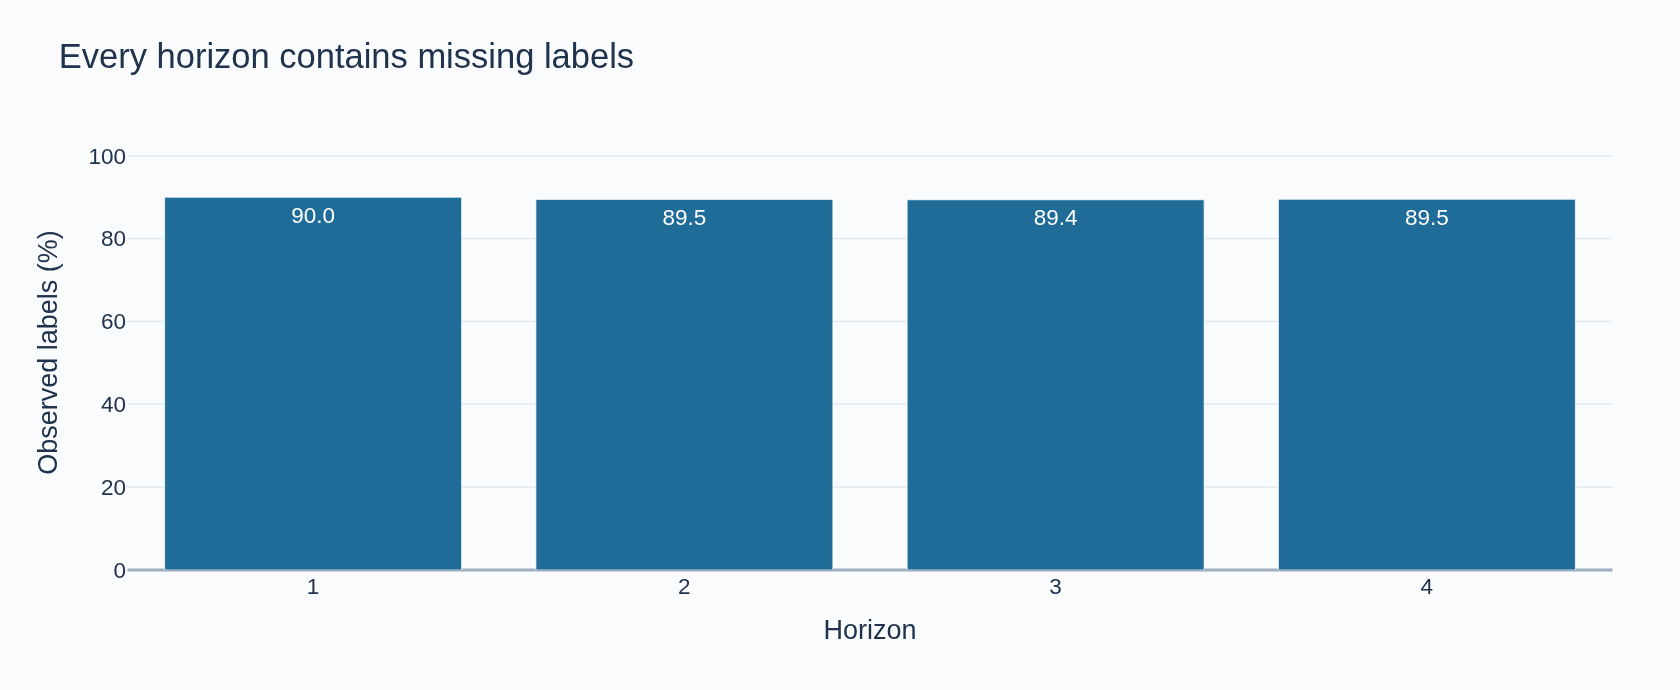

In [5]:
coverage = pd.DataFrame({"Horizon": [str(h) for h in range(1, 5)], "Observed labels (%)": [100 * y[pairs.loc[pairs.lag == h, "target"]].notna().mean().mean() for h in range(1, 5)]})
fig = px.bar(coverage, x="Horizon", y="Observed labels (%)", text_auto=".1f", title="Every horizon contains missing labels")
fig.update_traces(marker_color="#1F6C99")
fig.update_yaxes(range=[0, 105])
show_figure(fig, root, "target_coverage", 460)

## Implications for feature research

1. Use returns and volatility-normalized quantities to compare instruments with different units.
2. Preserve missing-market indicators and elapsed observation age.
3. Test relative market strength and pair spreads against a simple return reference.
4. Fit every imputer, scaler, and supervised screener inside the training interval.
5. Require improvements to survive time splits and feature-group ablations.

This EDA motivates hypotheses; it does not prove predictive value.